In [1]:
import scanpy as sc
import pandas as pd
import hisepy as hp
import matplotlib.pyplot as plt
import matplotlib as mpl

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

mpl.rcParams['pdf.fonttype'] = 42 

In [2]:
adata = sc.read_h5ad('../../data/figure-inputs/scrna_objects/final-pbmc-raw.h5ad')

In [3]:
visit_keep = ["Healthy", "PreTx", "EI", "ASCT60d", "ASCT1y"]

In [4]:
adata = adata[adata.obs["label.visitDetails"].isin(visit_keep)].copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [5]:
adata.obs["group"] = (
    adata.obs["aifi_plot_l3"].astype(str)
    + "_"
    + adata.obs["label.visitDetails"].astype(str)
)

visits = adata.obs["label.visitDetails"].unique().tolist()

In [6]:
celltypes_ordered = [
"cDC1",
"cDC2 CD14+",
"cDC2 Core",
"cDC2 HLA-DRhi",
"cDC2 ISG+",
"pDC",
"ASDC",
"CD14 Mono Core",
"CD14 Mono IL1B+",
"CD14 Mono ISG+",
"CD16 Mono C1Q+",
"CD16 Mono Core",
"CD16 Mono ISG+",
"Int Mono"
]

In [7]:
adata_sub = adata[adata.obs["aifi_plot_l3"].isin(celltypes_ordered)].copy()

group_order = [
    f"{ct}_{v}"
    for ct in celltypes_ordered
    for v in visits
    if f"{ct}_{v}" in adata.obs["group"].values
]

# set categorical
adata_sub.obs["group"] = adata_sub.obs["group"].astype("category")
adata_sub.obs["group"] = adata_sub.obs["group"].cat.set_categories(
    group_order,
    ordered=True
)

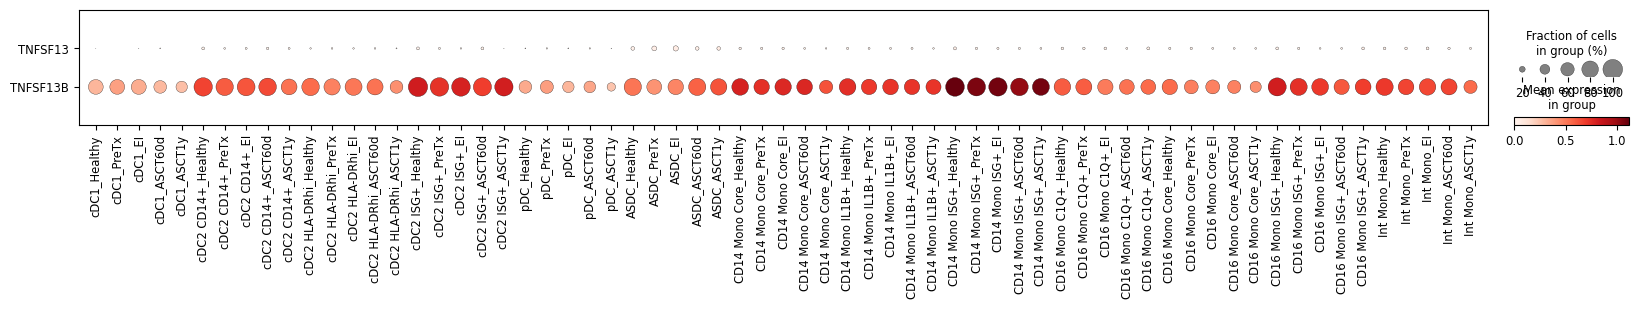

In [8]:
genes = ["TNFSF13", "TNFSF13B"]

sc.pl.dotplot(
    adata_sub,
    var_names=genes,
    groupby="group",
    dendrogram=False,
    swap_axes=True,
    show=False,
    figsize=(20, 1.5),
)
plt.savefig("../../data/figure-outputs/supplementary-7/sup_7j.pdf", dpi=200, bbox_inches="tight")